In [1]:
import amigo
import numpy as onp
from importlib import resources
from jax import scipy as jsp, numpy as np


def integrate_spectrum(filt, nwavels, wl_array, photon_flux):

    file_path = resources.files(amigo) / "data" / "filters" / f"{filt}.dat"
    filt_wls, _ = np.array(onp.loadtxt(file_path, unpack=True))

    edges = np.linspace(filt_wls.min(), filt_wls.max(), nwavels + 1)
    wavels = np.linspace(filt_wls.min(), filt_wls.max(), 2 * nwavels + 1)[1::2]

    areas = []
    for i in range(nwavels):
        cond1 = edges[i] < wl_array
        cond2 = wl_array < edges[i + 1]
        throughput = np.where(cond1 & cond2, photon_flux, 0)
        areas.append(jsp.integrate.trapezoid(y=throughput, x=wl_array))

    areas = np.array(areas)
    weights = areas / areas.sum()

    return wavels, weights

# Solar spectrum

In [ ]:
from expecto import get_spectrum

spectrum = get_spectrum(T_eff=5800, log_g=4.5, cache=True, vacuum=False)
air_spectrum = get_spectrum(T_eff=5800, log_g=4.5, cache=True, vacuum=True)

        Use Spectrum instead. [expecto.core]
        Use Spectrum instead. [expecto.core]


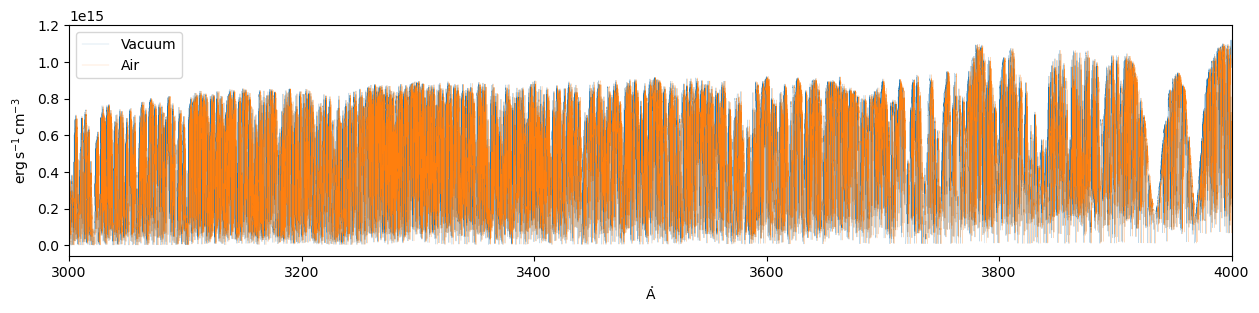

In [3]:
import matplotlib.pyplot as plt
from astropy.visualization import quantity_support

with quantity_support():
    plt.figure(figsize=(15, 3))
    plt.plot(spectrum.wavelength, spectrum.flux, label="Vacuum", linewidth=0.1)
    plt.plot(air_spectrum.wavelength, air_spectrum.flux, label="Air", linewidth=0.1)
    plt.xlim(3000, 4000)
    plt.legend()
    plt.show()

# Units of photons

In [4]:
from expecto import get_spectrum
import astropy.units as u

spec = get_spectrum(T_eff=4800, log_g=2.5, Z=0.0, cache=True)

# spec.spectral_axis: wavelength (Angstrom by default from PHOENIX grid)
# spec.flux: energy flux density, units taken directly from the FITS BUNIT header

flux_photon = spec.flux.to(
    u.photon / u.s / u.cm**2 / u.AA,
    equivalencies=u.spectral_density(spec.spectral_axis),
)

        Use Spectrum instead. [expecto.core]


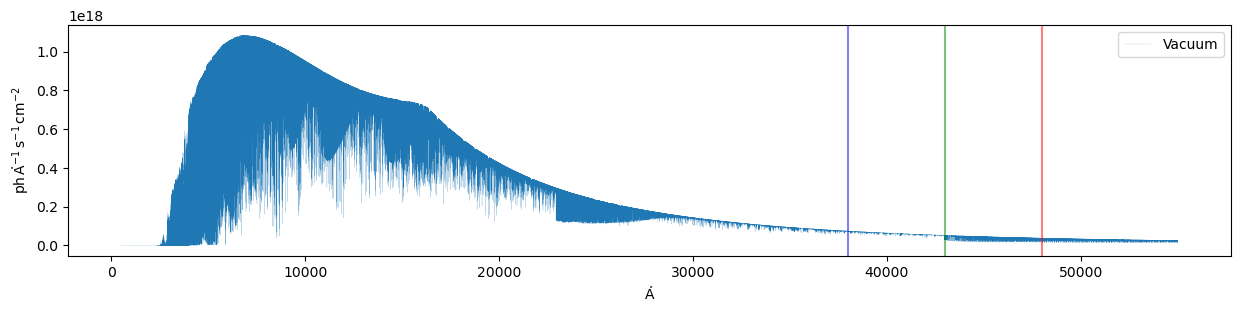

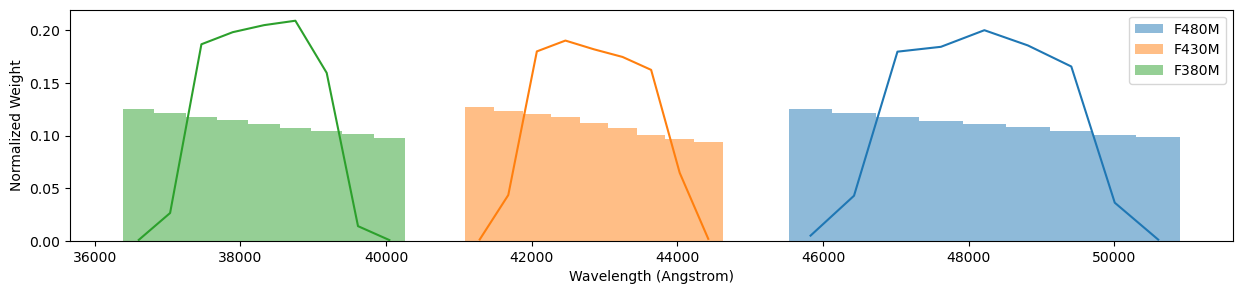

In [5]:
from amigo.misc import calc_throughput

with quantity_support():
    plt.figure(figsize=(15, 3))
    plt.plot(spec.wavelength, flux_photon, label="Vacuum", linewidth=0.1)
    # plt.xlim(3000, 4000)
    plt.axvline(4.8e4, color="red", alpha=0.5)
    plt.axvline(4.3e4, color="green", alpha=0.5)
    plt.axvline(3.8e4, color="blue", alpha=0.5)
    plt.legend()
    plt.show()

plt.figure(figsize=(15, 3))

for filt in ["F480M", "F430M", "F380M"]:
    wavels, weights = integrate_spectrum(
        filt, 9, np.asarray(spec.wavelength.to(u.AA).value), flux_photon
    )

    plt.bar(
        wavels,
        height=weights,
        width=np.diff(wavels).mean(),
        alpha=0.5,
        label=filt,
    )

    filt_wavels, filt_throughput = calc_throughput(filt, 9)
    filt_wavels *= 10_000_000
    filt_wavels *= 1_000
    plt.plot(
        filt_wavels,
        filt_throughput,
        # color="red",
        # alpha=0.5,
    )

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Normalized Weight")
# plt.title(filt)
plt.legend()
plt.show()

# HD 41094

In [6]:
from astroquery.simbad import Simbad

Simbad.add_votable_fields("ids")
result = Simbad.query_object("HD 41094")
# look through the IDS field for the "Gaia DR3 ..." identifier
print(result[0]["ids"])
"""
Gaia DR3 4756415013173305472
"""

TIC 149931517|Gaia DR3 4756415013173305472|2MASS J05582116-6409415|2MASSI J0558211-640941|CD-64   201|CPC 20.1  1382|CPD-64   503|GSC 08900-00244|HD  41094|MSX LMC 1668|PPM 355101|SAO 249405|TYC 8900-244-1|WISEA J055821.17-640940.2|Gaia DR1 4756415008869528832|Gaia DR2 4756415013173305472


'\nGaia DR3 4756415013173305472\n'

In [7]:
# from astroquery.gaia import Gaia

# source_id = 4756415013173305472

# query = f"""
# SELECT source_id, teff_gspphot, teff_gspphot_lower, teff_gspphot_upper,
#        logg_gspphot, logg_gspphot_lower, logg_gspphot_upper,
#        mh_gspphot, mh_gspphot_lower, mh_gspphot_upper,
#        libname_gspphot
# FROM gaiadr3.astrophysical_parameters
# WHERE source_id = {source_id}
# """

# job = Gaia.launch_job(query)
# result = job.get_results()
# print(result)

In [8]:
from expecto import get_spectrum

spec = get_spectrum(T_eff=4830, log_g=2.55, Z=-0.42, cache=True)

flux_photon = spec.flux.to(
    u.photon / u.s / u.cm**2 / u.AA,
    equivalencies=u.spectral_density(spec.spectral_axis),
)

        Use Spectrum instead. [expecto.core]


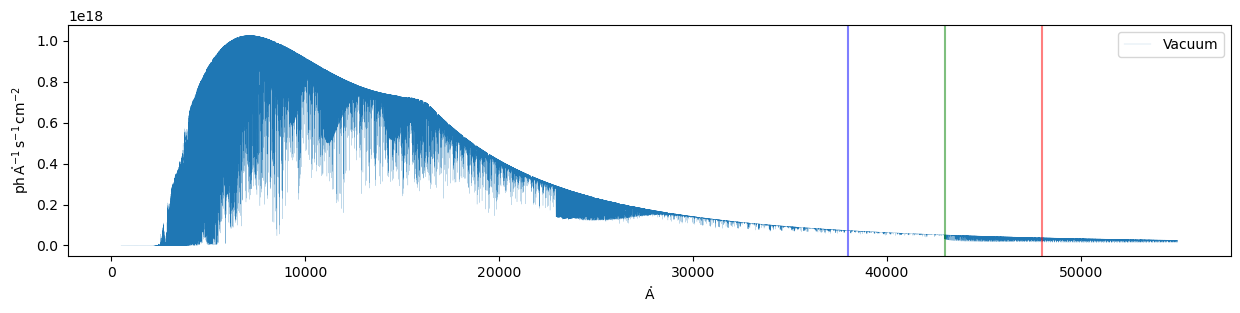

F480M -0.124362744 0.9999998
F430M -0.14548536 1.0
F380M -0.12454516 1.0000001


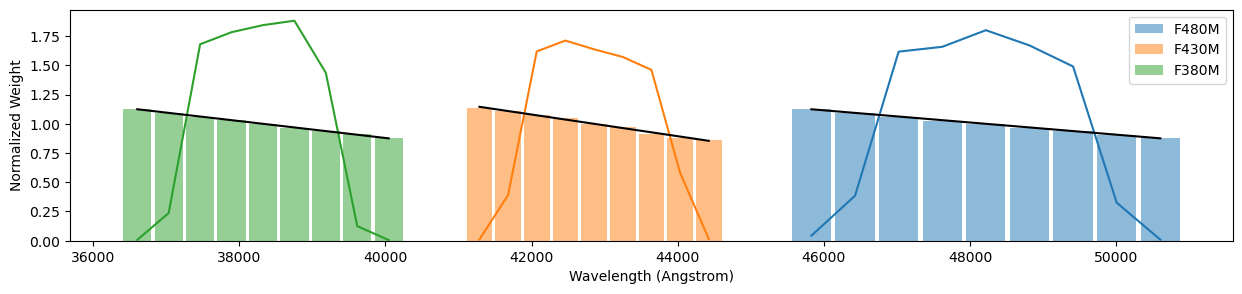

{'F480M': Array(-0.12436274, dtype=float32),
 'F430M': Array(-0.14548536, dtype=float32),
 'F380M': Array(-0.12454516, dtype=float32)}

In [9]:
from amigo.misc import calc_throughput

with quantity_support():
    plt.figure(figsize=(15, 3))
    plt.plot(spec.wavelength, flux_photon, label="Vacuum", linewidth=0.1)
    # plt.xlim(3000, 4000)
    plt.axvline(4.8e4, color="red", alpha=0.5)
    plt.axvline(4.3e4, color="green", alpha=0.5)
    plt.axvline(3.8e4, color="blue", alpha=0.5)
    plt.legend()
    plt.show()

slopes = {}

plt.figure(figsize=(15, 3))

for filt in ["F480M", "F430M", "F380M"]:
    wavels, weights = integrate_spectrum(
        filt, 9, np.asarray(spec.wavelength.to(u.AA).value), flux_photon
    )
    weights /= weights.mean()

    plt.bar(
        wavels,
        height=weights,
        width=0.9 * np.diff(wavels).mean(),
        alpha=0.5,
        label=filt,
    )

    filt_wavels, filt_throughput = calc_throughput(filt, 9)
    filt_wavels *= 10_000_000
    filt_wavels *= 1_000

    plt.plot(
        filt_wavels,
        filt_throughput / filt_throughput.mean(),
        # color="red",
        # alpha=0.5,
    )

    m, b = np.polyfit(wavels, weights, 1)
    plt.plot(wavels, m * wavels + b, color="black")

    xs = np.linspace(-1, 1, len(wavels), endpoint=True)
    m, b = np.polyfit(xs, weights, 1)
    print(filt, m, b)
    slopes[filt] = m


plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Normalized Weight")
# plt.title(filt)
plt.legend()
plt.show()

slopes

# EZ Aquarii

10.1088/0004-637X/804/1/64

In [10]:
from jax.tree import map
import numpy as onp


def MKs_to_rad(MKs):

    X = MKs
    a = 1.9515
    b = -0.3520
    c = 0.01680

    return a + b * X + c * X**2


def MKs_to_rad2(MKs, fe_H):

    X = MKs
    a = 1.9305
    b = -0.3466
    c = 0.01647
    f = 0.04458

    return (a + b * X + c * X**2) * (1 + f * fe_H)


def Ks_to_MKs(
    Ks,
    d_pc=1 / 0.2936,  # arcseconds
):
    """
    Convert Ks magnitude to absolute Ks magnitude (MKs)
    """
    return Ks - 5 * np.log10(d_pc / 10)


from scipy.optimize import brentq


def R_to_Teff(
    Y,
    Trange=(2500, 3500),
    a=10.5440,
    b=-33.7546,
    c=35.1909,
    d=-11.5928,
):

    Tmin, Tmax = Trange

    coeffs = [d, c, b, a - Y]

    roots = onp.roots(coeffs)
    real_roots = roots[onp.isclose(roots.imag, 0)].real

    Teffs = real_roots * 3500

    # Apply astrophysical prior
    Teffs = Teffs[(Teffs >= Tmin) & (Teffs <= Tmax)]

    if len(Teffs) != 1:
        print(
            f"WARNING: Ambiguous Teff for R={Y}: candidates={Teffs}. Choosing the hotter option {np.max(Teffs)}."
        )

    return np.max(Teffs)


def MR_to_logg(M, R):
    return 4.438 + np.log10(M) - 2 * np.log10(R)


"""From How to Constrain your M-Dwarf Mann. et al 2015, 2019"""
masses = {"A": 0.1187, "B": 0.1145, "C": 0.0930}  # solar masses
print(f"masses: {masses}")
Kss = {"A": 6.557, "B": 6.593, "C": 7.127}  # mag
print(f"Kss: {Kss}")
MKss = map(Ks_to_MKs, Kss)
print(f"MKs: {MKss}")
Rs = map(MKs_to_rad, MKss)  # in units of solar radii
Teff_ranges = {"A": (2800, 3300), "B": (2800, 3300), "C": (2500, 2900)}  # K
print(f"Rs: {Rs}")
Teffs = map(R_to_Teff, Rs, Teff_ranges)  # in units of solar radii
print(f"Teffs: {Teffs}")
loggs = map(MR_to_logg, masses, Rs)  # in units of solar radii, logg in cgs units
print(f"loggs: {loggs}")

masses: {'A': 0.1187, 'B': 0.1145, 'C': 0.093}
Kss: {'A': 6.557, 'B': 6.593, 'C': 7.127}
MKs: {'A': Array(8.895781, dtype=float32), 'B': Array(8.93178, dtype=float32), 'C': Array(9.46578, dtype=float32)}
Rs: {'A': Array(0.14965177, dtype=float32), 'B': Array(0.14776206, dtype=float32), 'C': Array(0.12484205, dtype=float32)}
Teffs: {'A': Array(2939.6428, dtype=float32), 'B': Array(2931.4922, dtype=float32), 'C': Array(2765.921, dtype=float32)}
loggs: {'A': Array(5.162287, dtype=float32), 'B': Array(5.15768, dtype=float32), 'C': Array(5.2137613, dtype=float32)}


In [11]:
from expecto import get_spectrum

A_kwargs = {"T_eff": Teffs["A"], "log_g": loggs["A"]}
B_kwargs = {"T_eff": Teffs["B"], "log_g": loggs["B"]}
C_kwargs = {"T_eff": Teffs["C"], "log_g": loggs["C"]}


A_spec = get_spectrum(**A_kwargs, cache=True)
B_spec = get_spectrum(**B_kwargs, cache=True)
C_spec = get_spectrum(**C_kwargs, cache=True)

A_flux_photon = A_spec.flux.to(
    u.photon / u.s / u.cm**2 / u.AA,
    equivalencies=u.spectral_density(A_spec.spectral_axis),
)

B_flux_photon = B_spec.flux.to(
    u.photon / u.s / u.cm**2 / u.AA,
    equivalencies=u.spectral_density(B_spec.spectral_axis),
)

C_flux_photon = C_spec.flux.to(
    u.photon / u.s / u.cm**2 / u.AA,
    equivalencies=u.spectral_density(C_spec.spectral_axis),
)

AC_flux_photon = A_flux_photon + C_flux_photon

        Use Spectrum instead. [expecto.core]
        Use Spectrum instead. [expecto.core]
        Use Spectrum instead. [expecto.core]


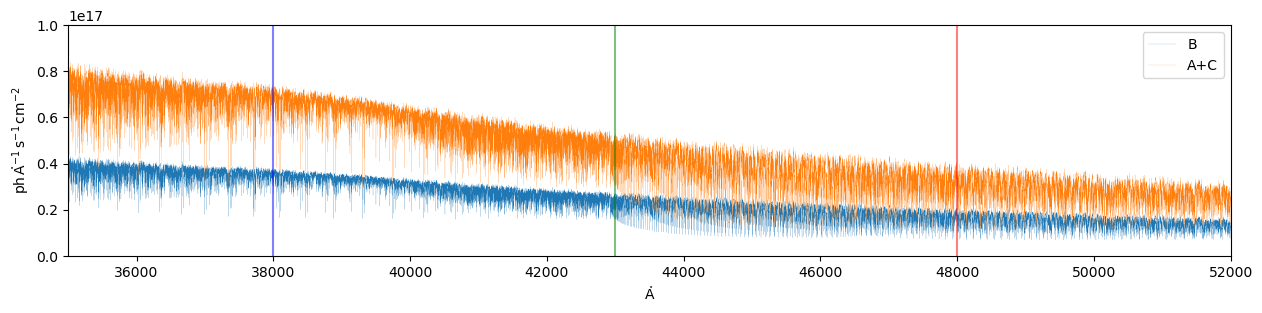

In [12]:
with quantity_support():
    plt.figure(figsize=(15, 3))
    # plt.plot(A_spec.wavelength, A_flux_photon, label="A", linewidth=0.1)
    plt.plot(B_spec.wavelength, B_flux_photon, label="B", linewidth=0.1)
    # plt.plot(C_spec.wavelength, C_flux_photon, label="C", linewidth=0.1)
    plt.plot(C_spec.wavelength, AC_flux_photon, label="A+C", linewidth=0.1)
    plt.xlim(3.5e4, 5.2e4)
    plt.ylim(0, 1e17)
    plt.axvline(4.8e4, color="red", alpha=0.5)
    plt.axvline(4.3e4, color="green", alpha=0.5)
    plt.axvline(3.8e4, color="blue", alpha=0.5)
    plt.legend()
    plt.show()

## A+C

F480M -0.12971859 0.99999994
F430M -0.14906244 1.0
F380M -0.07376706 1.0000001


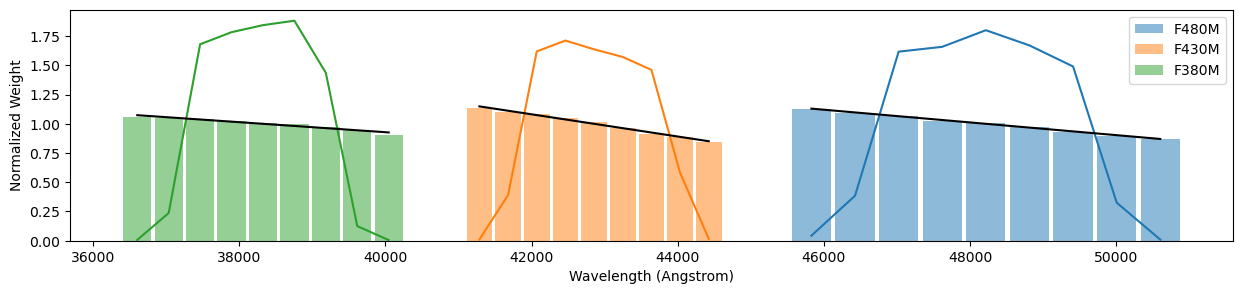

{'F480M': Array(-0.12971859, dtype=float32),
 'F430M': Array(-0.14906244, dtype=float32),
 'F380M': Array(-0.07376706, dtype=float32)}

In [13]:
from amigo.misc import calc_throughput

slopes = {}

plt.figure(figsize=(15, 3))

for filt in ["F480M", "F430M", "F380M"]:
    wavels, weights = integrate_spectrum(
        filt,
        9,
        np.asarray(A_spec.wavelength.to(u.AA).value),
        A_flux_photon + C_flux_photon,
    )
    weights /= weights.mean()

    plt.bar(
        wavels,
        height=weights,
        width=0.9 * np.diff(wavels).mean(),
        alpha=0.5,
        label=filt,
    )

    filt_wavels, filt_throughput = calc_throughput(filt, 9)
    filt_wavels *= 10_000_000
    filt_wavels *= 1_000

    plt.plot(
        filt_wavels,
        filt_throughput / filt_throughput.mean(),
        # color="red",
        # alpha=0.5,
    )

    m, b = np.polyfit(wavels, weights, 1)
    plt.plot(wavels, m * wavels + b, color="black")

    xs = np.linspace(-1, 1, len(wavels), endpoint=True)
    m, b = np.polyfit(xs, weights, 1)
    print(filt, m, b)
    slopes[filt] = m


plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Normalized Weight")
# plt.title(filt)
plt.legend()
plt.show()

slopes

## B

F480M -0.12976371 1.0
F430M -0.14530317 1.0
F380M -0.07606107 1.0000001


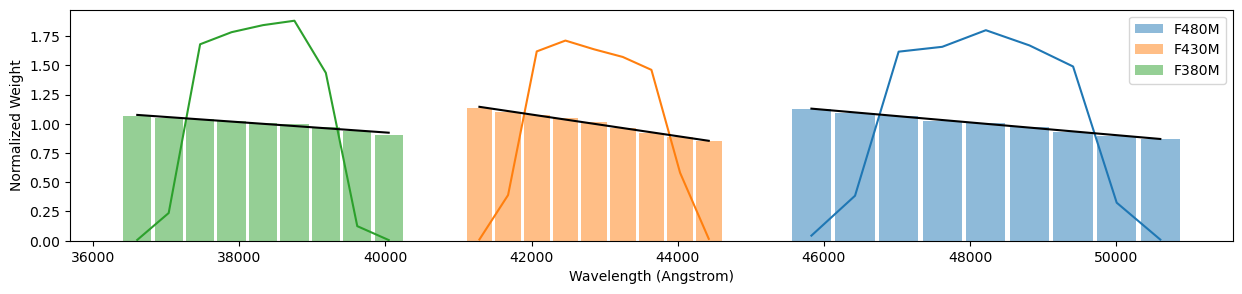

{'F480M': Array(-0.12976371, dtype=float32),
 'F430M': Array(-0.14530317, dtype=float32),
 'F380M': Array(-0.07606107, dtype=float32)}

In [14]:
from amigo.misc import calc_throughput

slopes = {}

plt.figure(figsize=(15, 3))

for filt in ["F480M", "F430M", "F380M"]:
    wavels, weights = integrate_spectrum(
        filt,
        9,
        np.asarray(B_spec.wavelength.to(u.AA).value),
        B_flux_photon,
    )
    weights /= weights.mean()

    plt.bar(
        wavels,
        height=weights,
        width=0.9 * np.diff(wavels).mean(),
        alpha=0.5,
        label=filt,
    )

    filt_wavels, filt_throughput = calc_throughput(filt, 9)
    filt_wavels *= 10_000_000
    filt_wavels *= 1_000

    plt.plot(
        filt_wavels,
        filt_throughput / filt_throughput.mean(),
        # color="red",
        # alpha=0.5,
    )

    m, b = np.polyfit(wavels, weights, 1)
    plt.plot(wavels, m * wavels + b, color="black")

    xs = np.linspace(-1, 1, len(wavels), endpoint=True)
    m, b = np.polyfit(xs, weights, 1)
    print(filt, m, b)
    slopes[filt] = m


plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Normalized Weight")
# plt.title(filt)
plt.legend()
plt.show()

slopes